<a href="https://colab.research.google.com/github/Somrat390/Pytorch/blob/main/Neural_Network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
torch.__version__

'2.11.0+cu128'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
import sklearn

In [4]:
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples, noise=0.3, random_state=42)

In [5]:
len(X), len(y)

(1000, 1000)

In [6]:
X[:5], y[:5]

(array([[ 0.59171471,  0.43674853],
        [-0.45745002,  0.36160118],
        [-1.01069349,  0.83042101],
        [-0.87169639,  0.41407292],
        [ 0.48803455, -0.87258708]]),
 array([1, 1, 1, 1, 0]))

In [7]:
import pandas as pd

circles = pd.DataFrame({"X1" : X[:, 0],
                       "X2" : X[:,1],
                       "label" : y})
circles.head(10)

,X1,X2,label
0,0.591715,0.436749,1
1,-0.457450,0.361601,1
2,-1.010693,0.830421,1
3,-0.871696,0.414073,1
4,0.488035,-0.872587,0
5,-0.347874,1.103071,1
6,-0.046008,0.834056,1
7,0.610994,0.306608,1
8,-0.255312,-0.879601,1
9,0.025255,1.300938,0


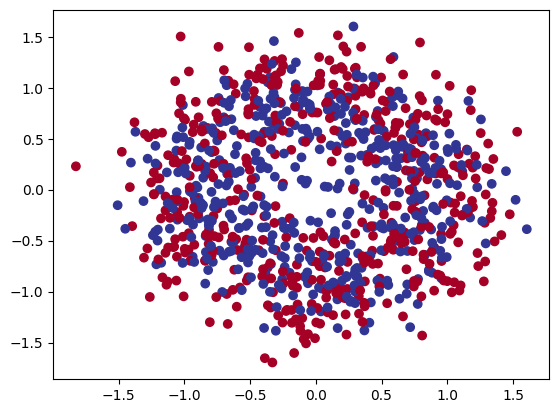

In [8]:
#visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c = y,
            cmap = plt.cm.RdYlBu)

In [9]:
# Checking input and poutput shapes
X.shape, y.shape

((1000, 2), (1000,))

In [10]:
X_sample = X[0]
y_sample = y[0]

X_sample, y_sample, X_sample.shape, y_sample.shape

(array([0.59171471, 0.43674853]), np.int64(1), (2,), ())

# Trun the data into Tensor

In [11]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [12]:
X[:5], y[:5]

(tensor([[ 0.5917,  0.4367],
         [-0.4575,  0.3616],
         [-1.0107,  0.8304],
         [-0.8717,  0.4141],
         [ 0.4880, -0.8726]]),
 tensor([1., 1., 1., 1., 0.]))

In [13]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [14]:
# Split data into  train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)


In [15]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

# Building the Model

In [19]:
class CircleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=1)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x))


model_0 = CircleModel().to(device)
model_0

CircleModel(
  (layer_1): Linear(in_features=2, out_features=1, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)